In [1]:
#Importing Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
# ==========================================
# 1. DATA LOADING AND CLEANING
# ==========================================
# Load the dataset. Ensuring the CSV has 'Name' and 'Smiles' columns.
df = pd.read_excel('Compounds.xlsx')
df.columns = [c.strip() for c in df.columns] # Remove accidental whitespace in headers

In [5]:
# ==========================================
# 2. MOLECULAR DESCRIPTOR CALCULATION
# ==========================================
# This section uses RDKit to calculate physical properties used in drug discovery.
def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return {
            'MW': Descriptors.MolWt(mol),          # Molecular Weight
            'LogP': Descriptors.MolLogP(mol),      # Octanol-water partition coefficient
            'HBD': Lipinski.NumHDonors(mol),       # Hydrogen Bond Donors
            'HBA': Lipinski.NumHAcceptors(mol),    # Hydrogen Bond Acceptors
            'TPSA': Descriptors.TPSA(mol),         # Topological Polar Surface Area
            'RotB': Lipinski.NumRotatableBonds(mol)# Number of Rotatable Bonds
        }
    return None

results = []
valid_indices = []
for idx, row in df.iterrows():
    desc = calculate_descriptors(row['Smiles'])
    if desc:
        results.append(desc)
        valid_indices.append(idx)

[17:34:00] Explicit valence for atom # 4 O, 3, is greater than permitted
[17:34:00] Explicit valence for atom # 1 C, 5, is greater than permitted
[17:34:00] Explicit valence for atom # 4 O, 3, is greater than permitted
[17:34:00] Explicit valence for atom # 5 O, 3, is greater than permitted
[17:34:00] Explicit valence for atom # 4 O, 3, is greater than permitted
[17:34:00] Explicit valence for atom # 4 O, 3, is greater than permitted
[17:34:00] Explicit valence for atom # 4 O, 3, is greater than permitted
[17:34:00] Explicit valence for atom # 4 O, 3, is greater than permitted
[17:34:00] Explicit valence for atom # 4 O, 3, is greater than permitted
[17:34:00] Explicit valence for atom # 7 O, 3, is greater than permitted
[17:34:00] Explicit valence for atom # 18 O, 4, is greater than permitted
[17:34:00] Explicit valence for atom # 18 O, 4, is greater than permitted


In [6]:
# Merge descriptors back with original names
desc_df = pd.DataFrame(results)
processed_df = df.iloc[valid_indices].reset_index(drop=True)
processed_df = pd.concat([processed_df, desc_df], axis=1)

In [7]:
# ==========================================
# 3. PHARMACOKINETICS & DRUG-LIKENESS FILTERS
# ==========================================
# Lipinski's Rule of Five (Ro5)
processed_df['MW_pass'] = processed_df['MW'] <= 500
processed_df['LogP_pass'] = processed_df['LogP'] <= 5
processed_df['HBD_pass'] = processed_df['HBD'] <= 5
processed_df['HBA_pass'] = processed_df['HBA'] <= 10

In [8]:
# A compound is generally accepted if it has <= 1 violation of Lipinski rules
processed_df['Lipinski_Violations'] = 4 - (processed_df[['MW_pass', 'LogP_pass', 'HBD_pass', 'HBA_pass']].sum(axis=1))
processed_df['Lipinski_Pass'] = processed_df['Lipinski_Violations'] <= 1

In [9]:
# Veber's Rule (Good for predicting oral bioavailability)
# Rotatable Bonds <= 10 and TPSA <= 140
processed_df['Veber_Pass'] = (processed_df['RotB'] <= 10) & (processed_df['TPSA'] <= 140)

In [10]:
# Final Drug-Like Screening
processed_df['Drug_Like'] = processed_df['Lipinski_Pass'] & processed_df['Veber_Pass']

In [11]:
# Save output
processed_df.to_csv('Screened_Compounds_Results.csv', index=False)

In [14]:
# ==========================================
# 4. PUBLICATION-QUALITY VISUALIZATIONS
# ==========================================
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 600})

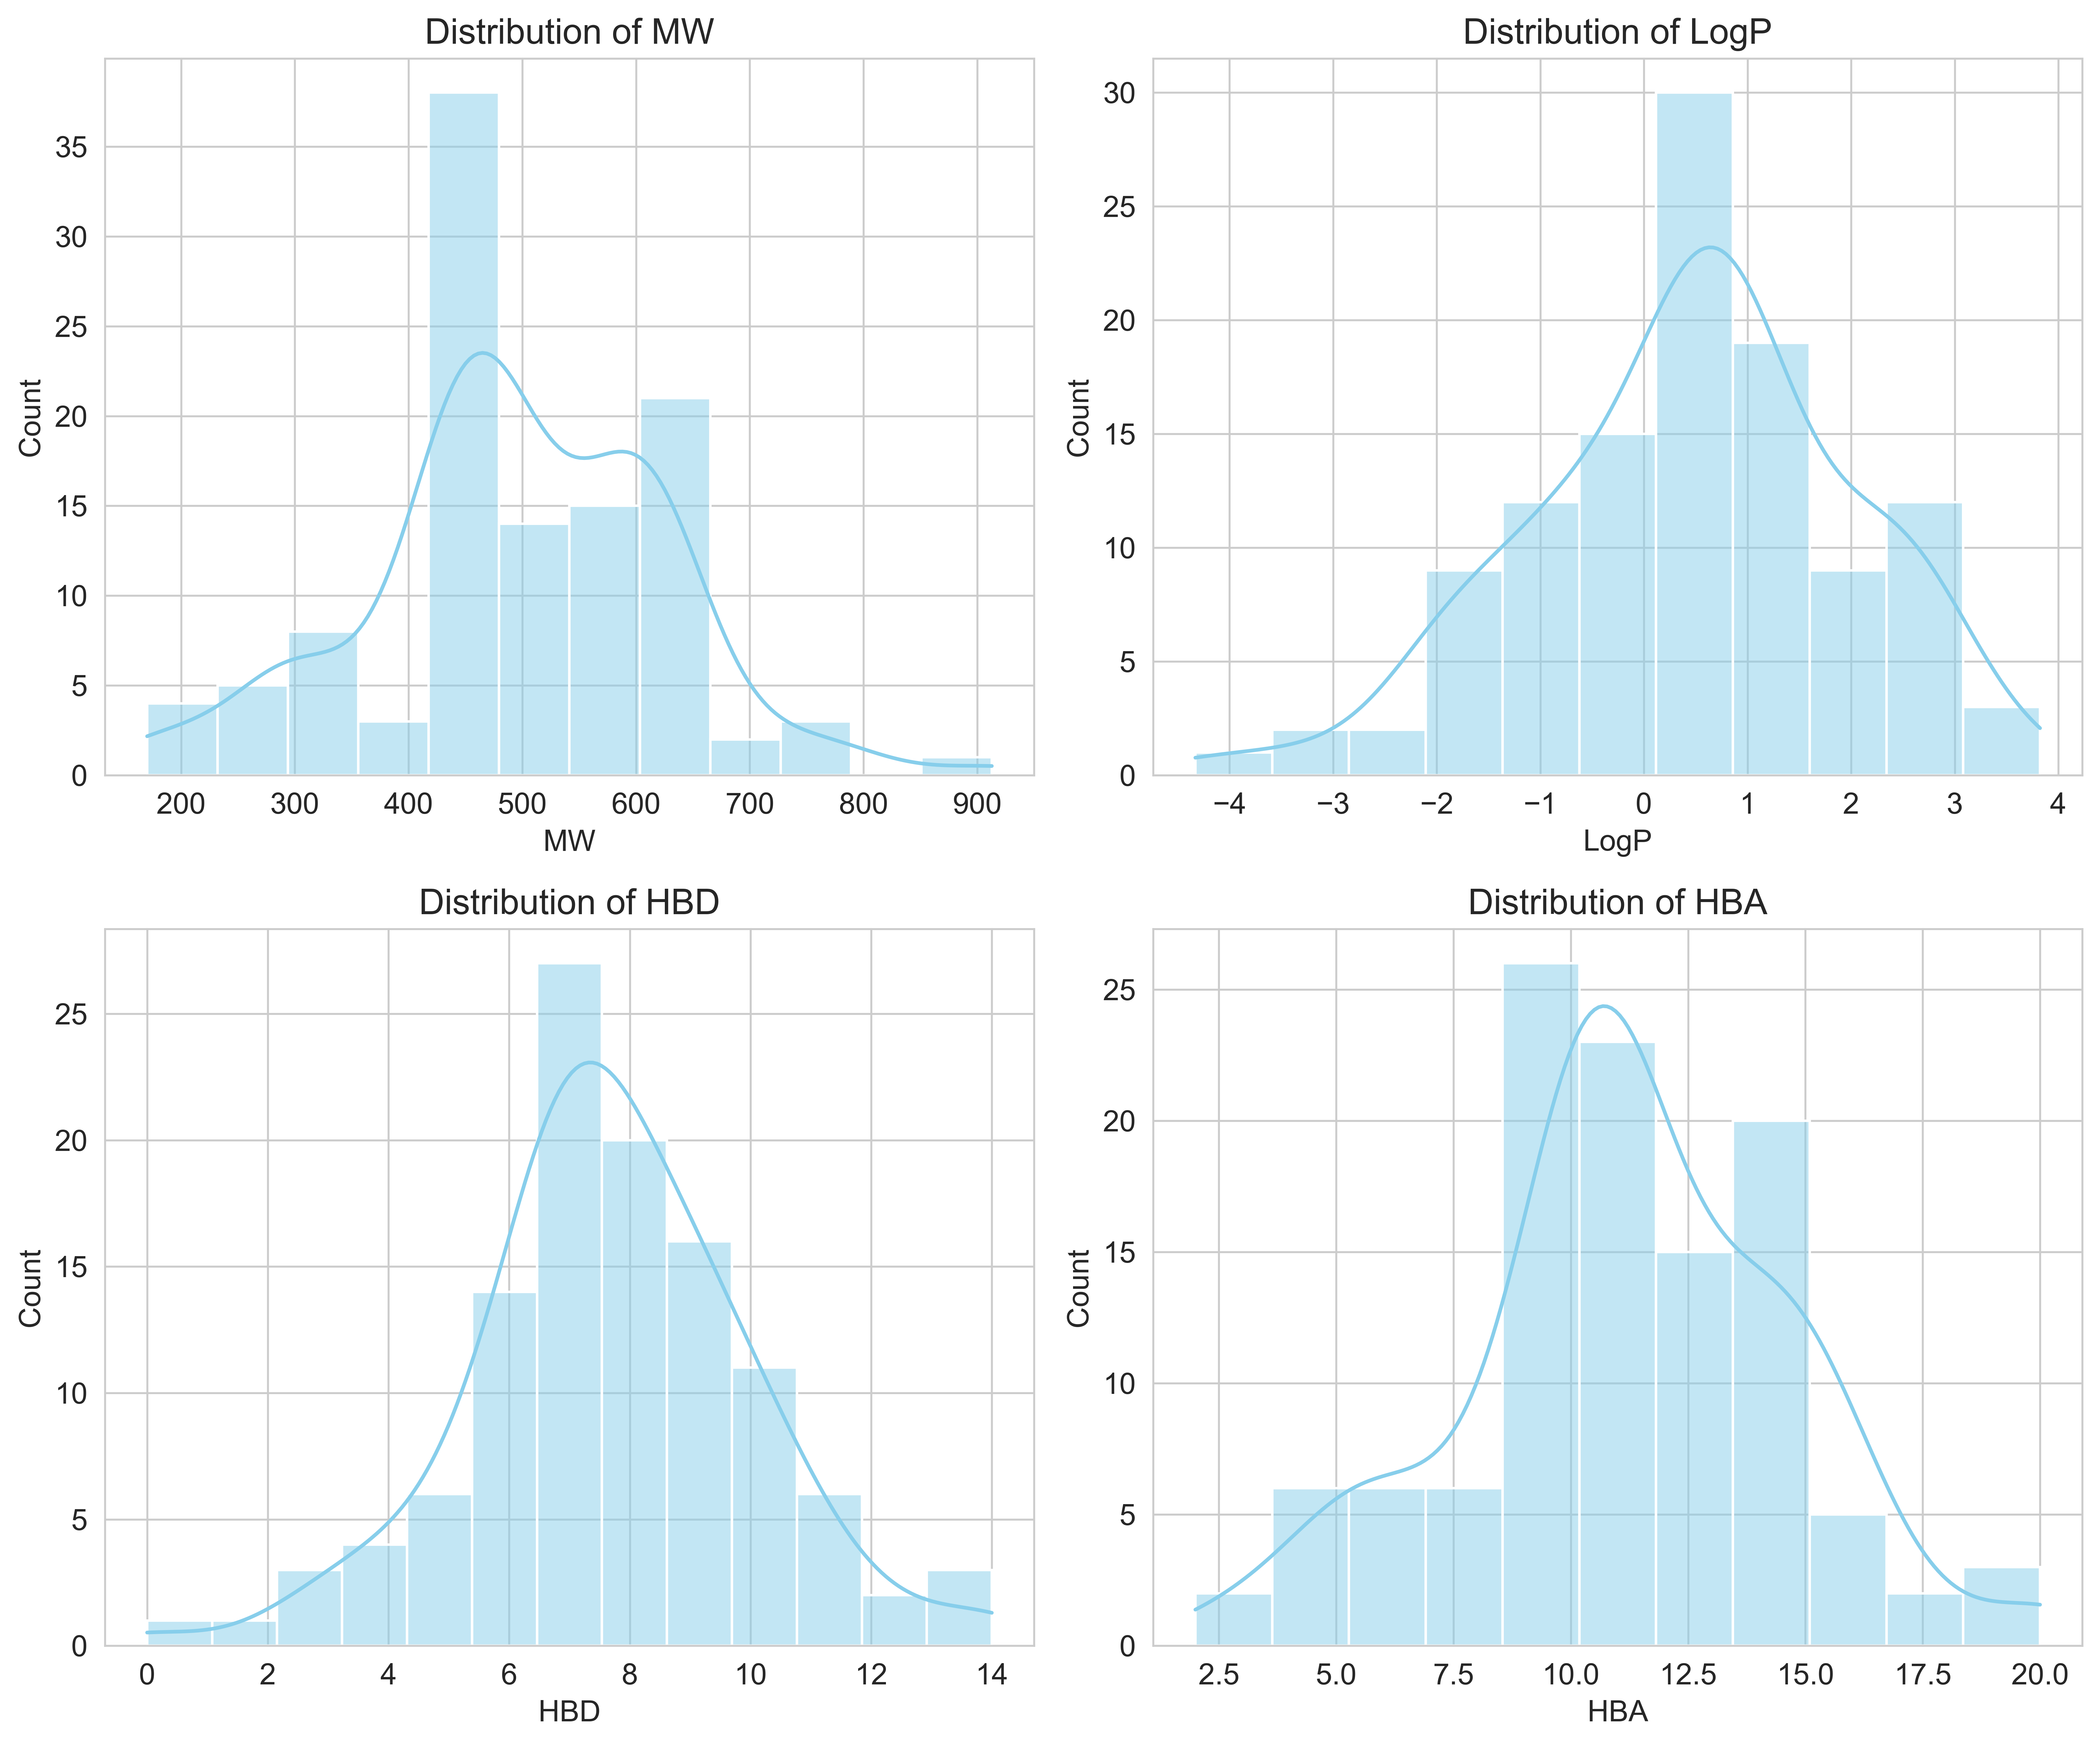

In [15]:
# A. Descriptor Distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cols = ['MW', 'LogP', 'HBD', 'HBA']
for i, col in enumerate(cols):
    sns.histplot(processed_df[col], kde=True, ax=axes[i//2, i%2], color='skyblue')
    axes[i//2, i%2].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('Descriptor_Distributions.png')

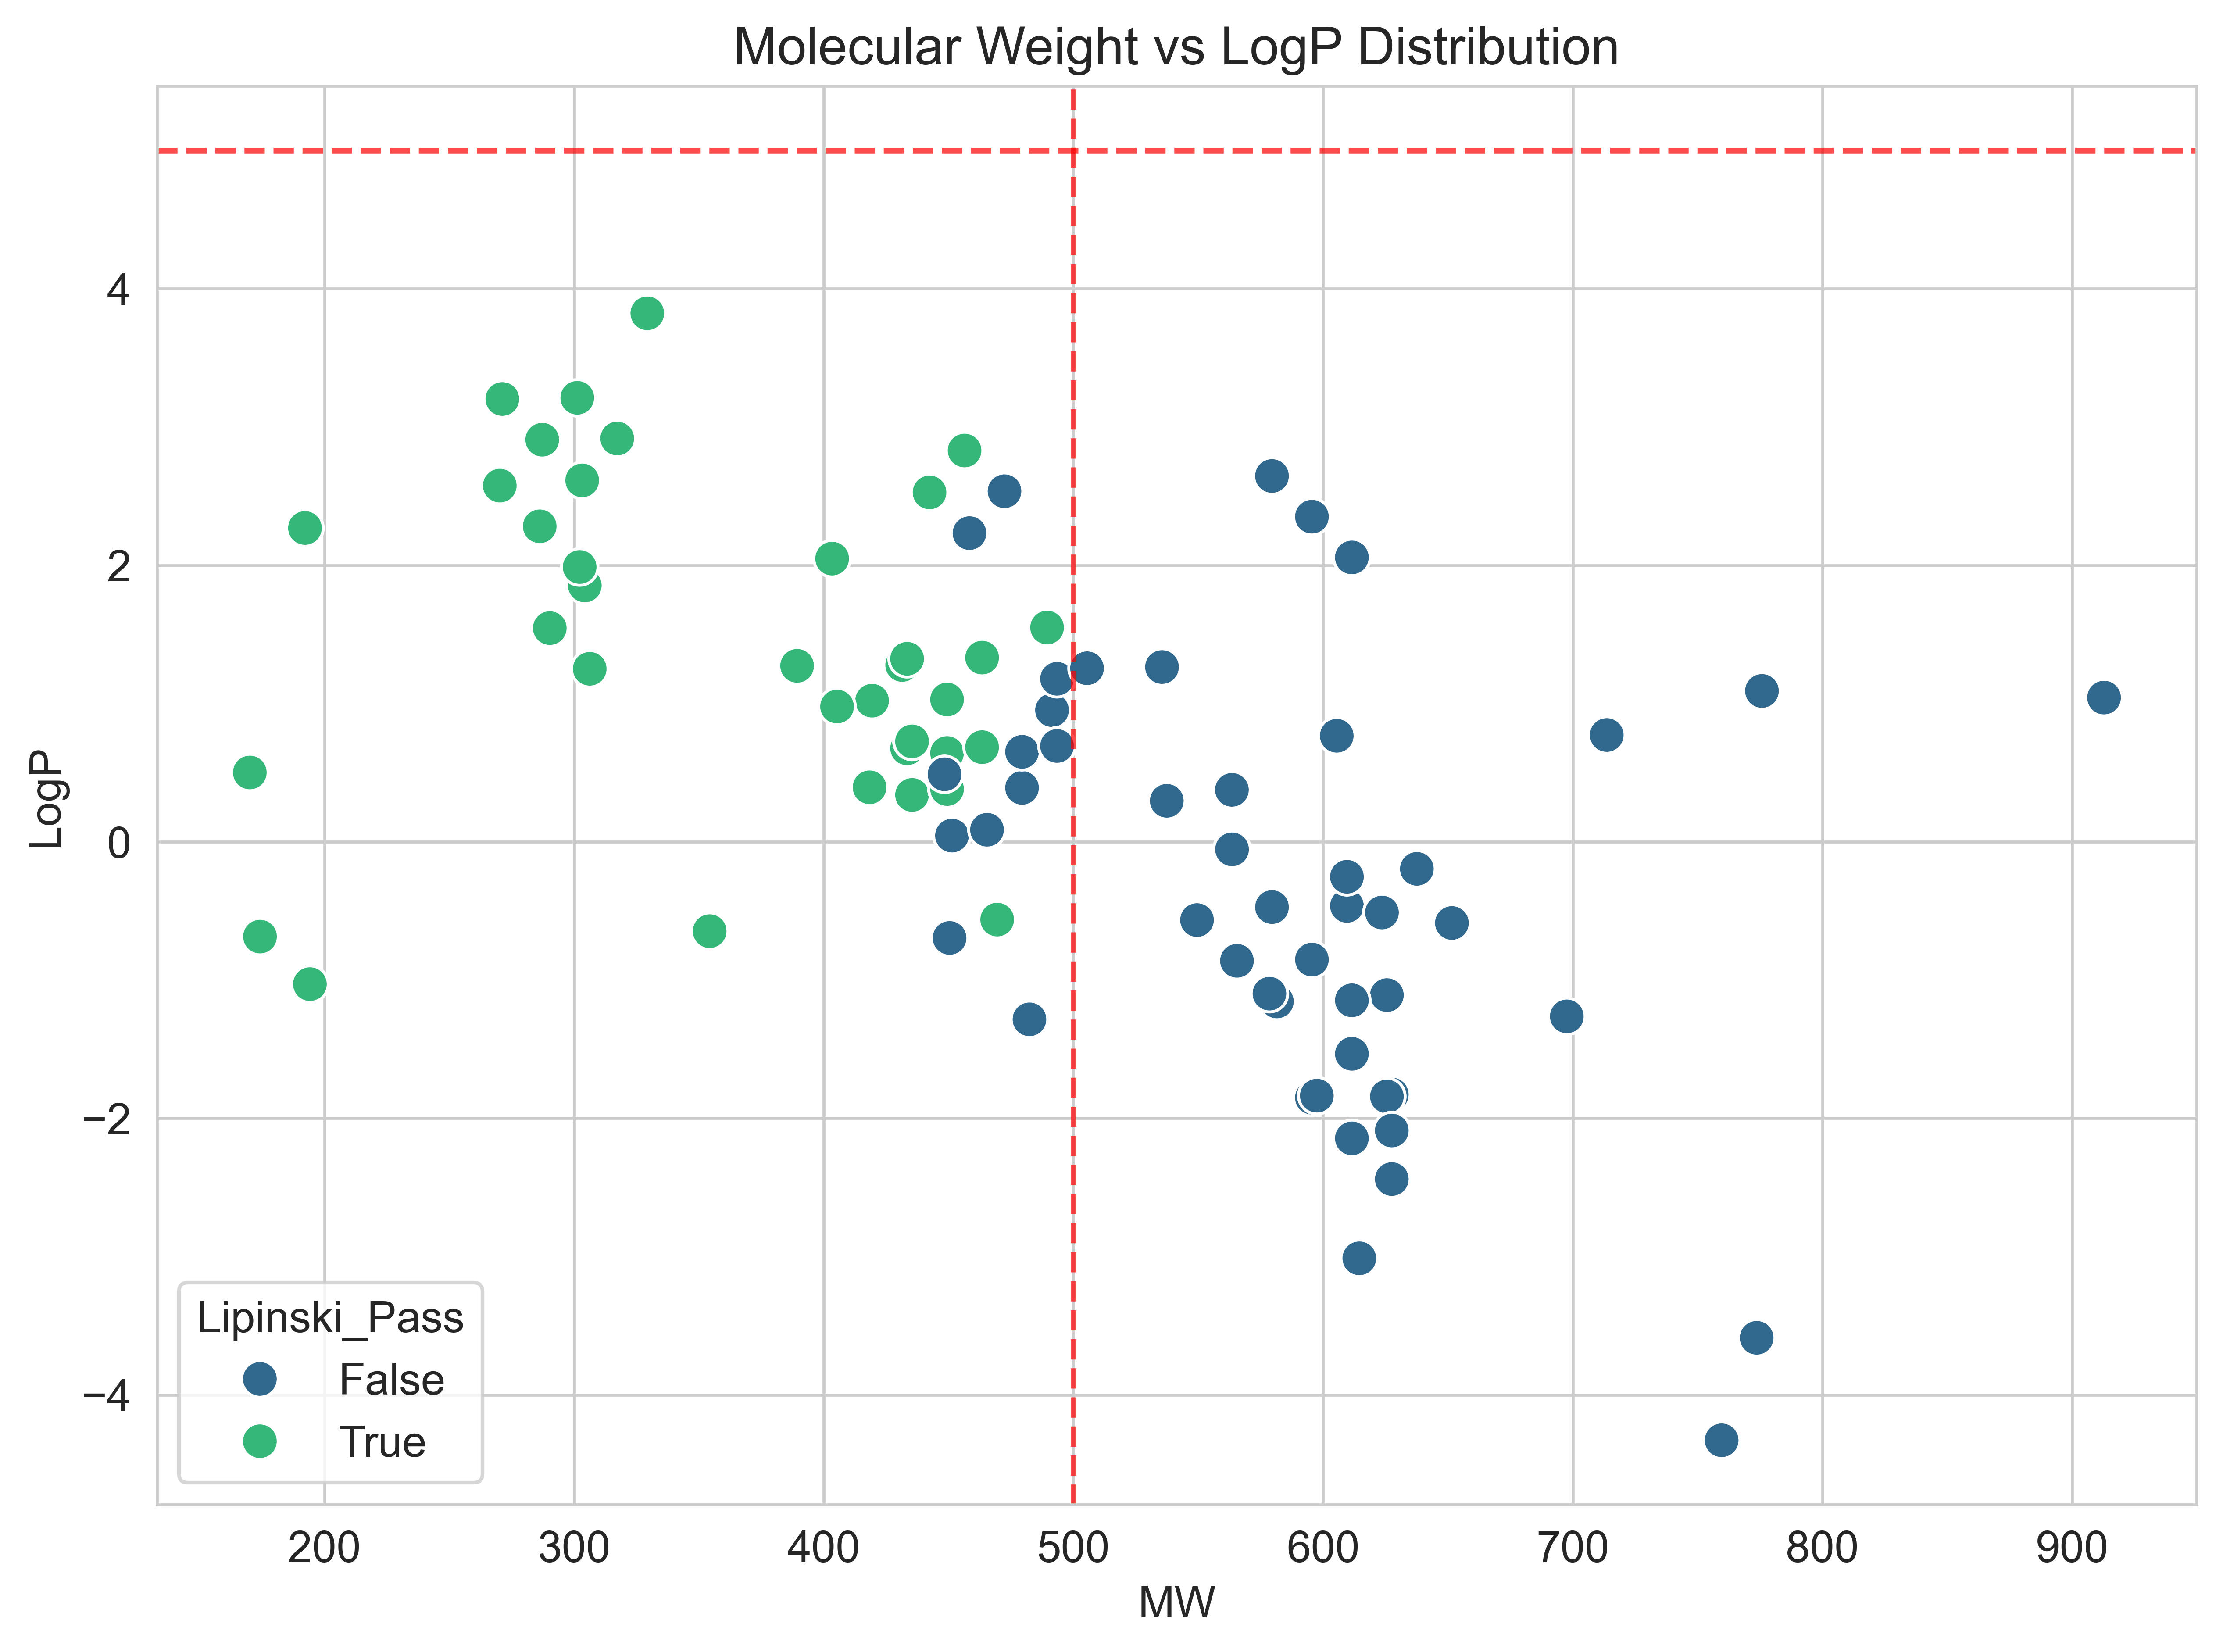

In [16]:
# B. MW vs LogP Scatter Plot (Chemical Space)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=processed_df, x='MW', y='LogP', hue='Lipinski_Pass', palette='viridis', s=100)
plt.axhline(5, color='red', linestyle='--', alpha=0.7, label='LogP Limit')
plt.axvline(500, color='red', linestyle='--', alpha=0.7, label='MW Limit')
plt.title('Molecular Weight vs LogP Distribution')
plt.savefig('MW_vs_LogP.png')

Screening and Visualization Complete. Files saved to directory.


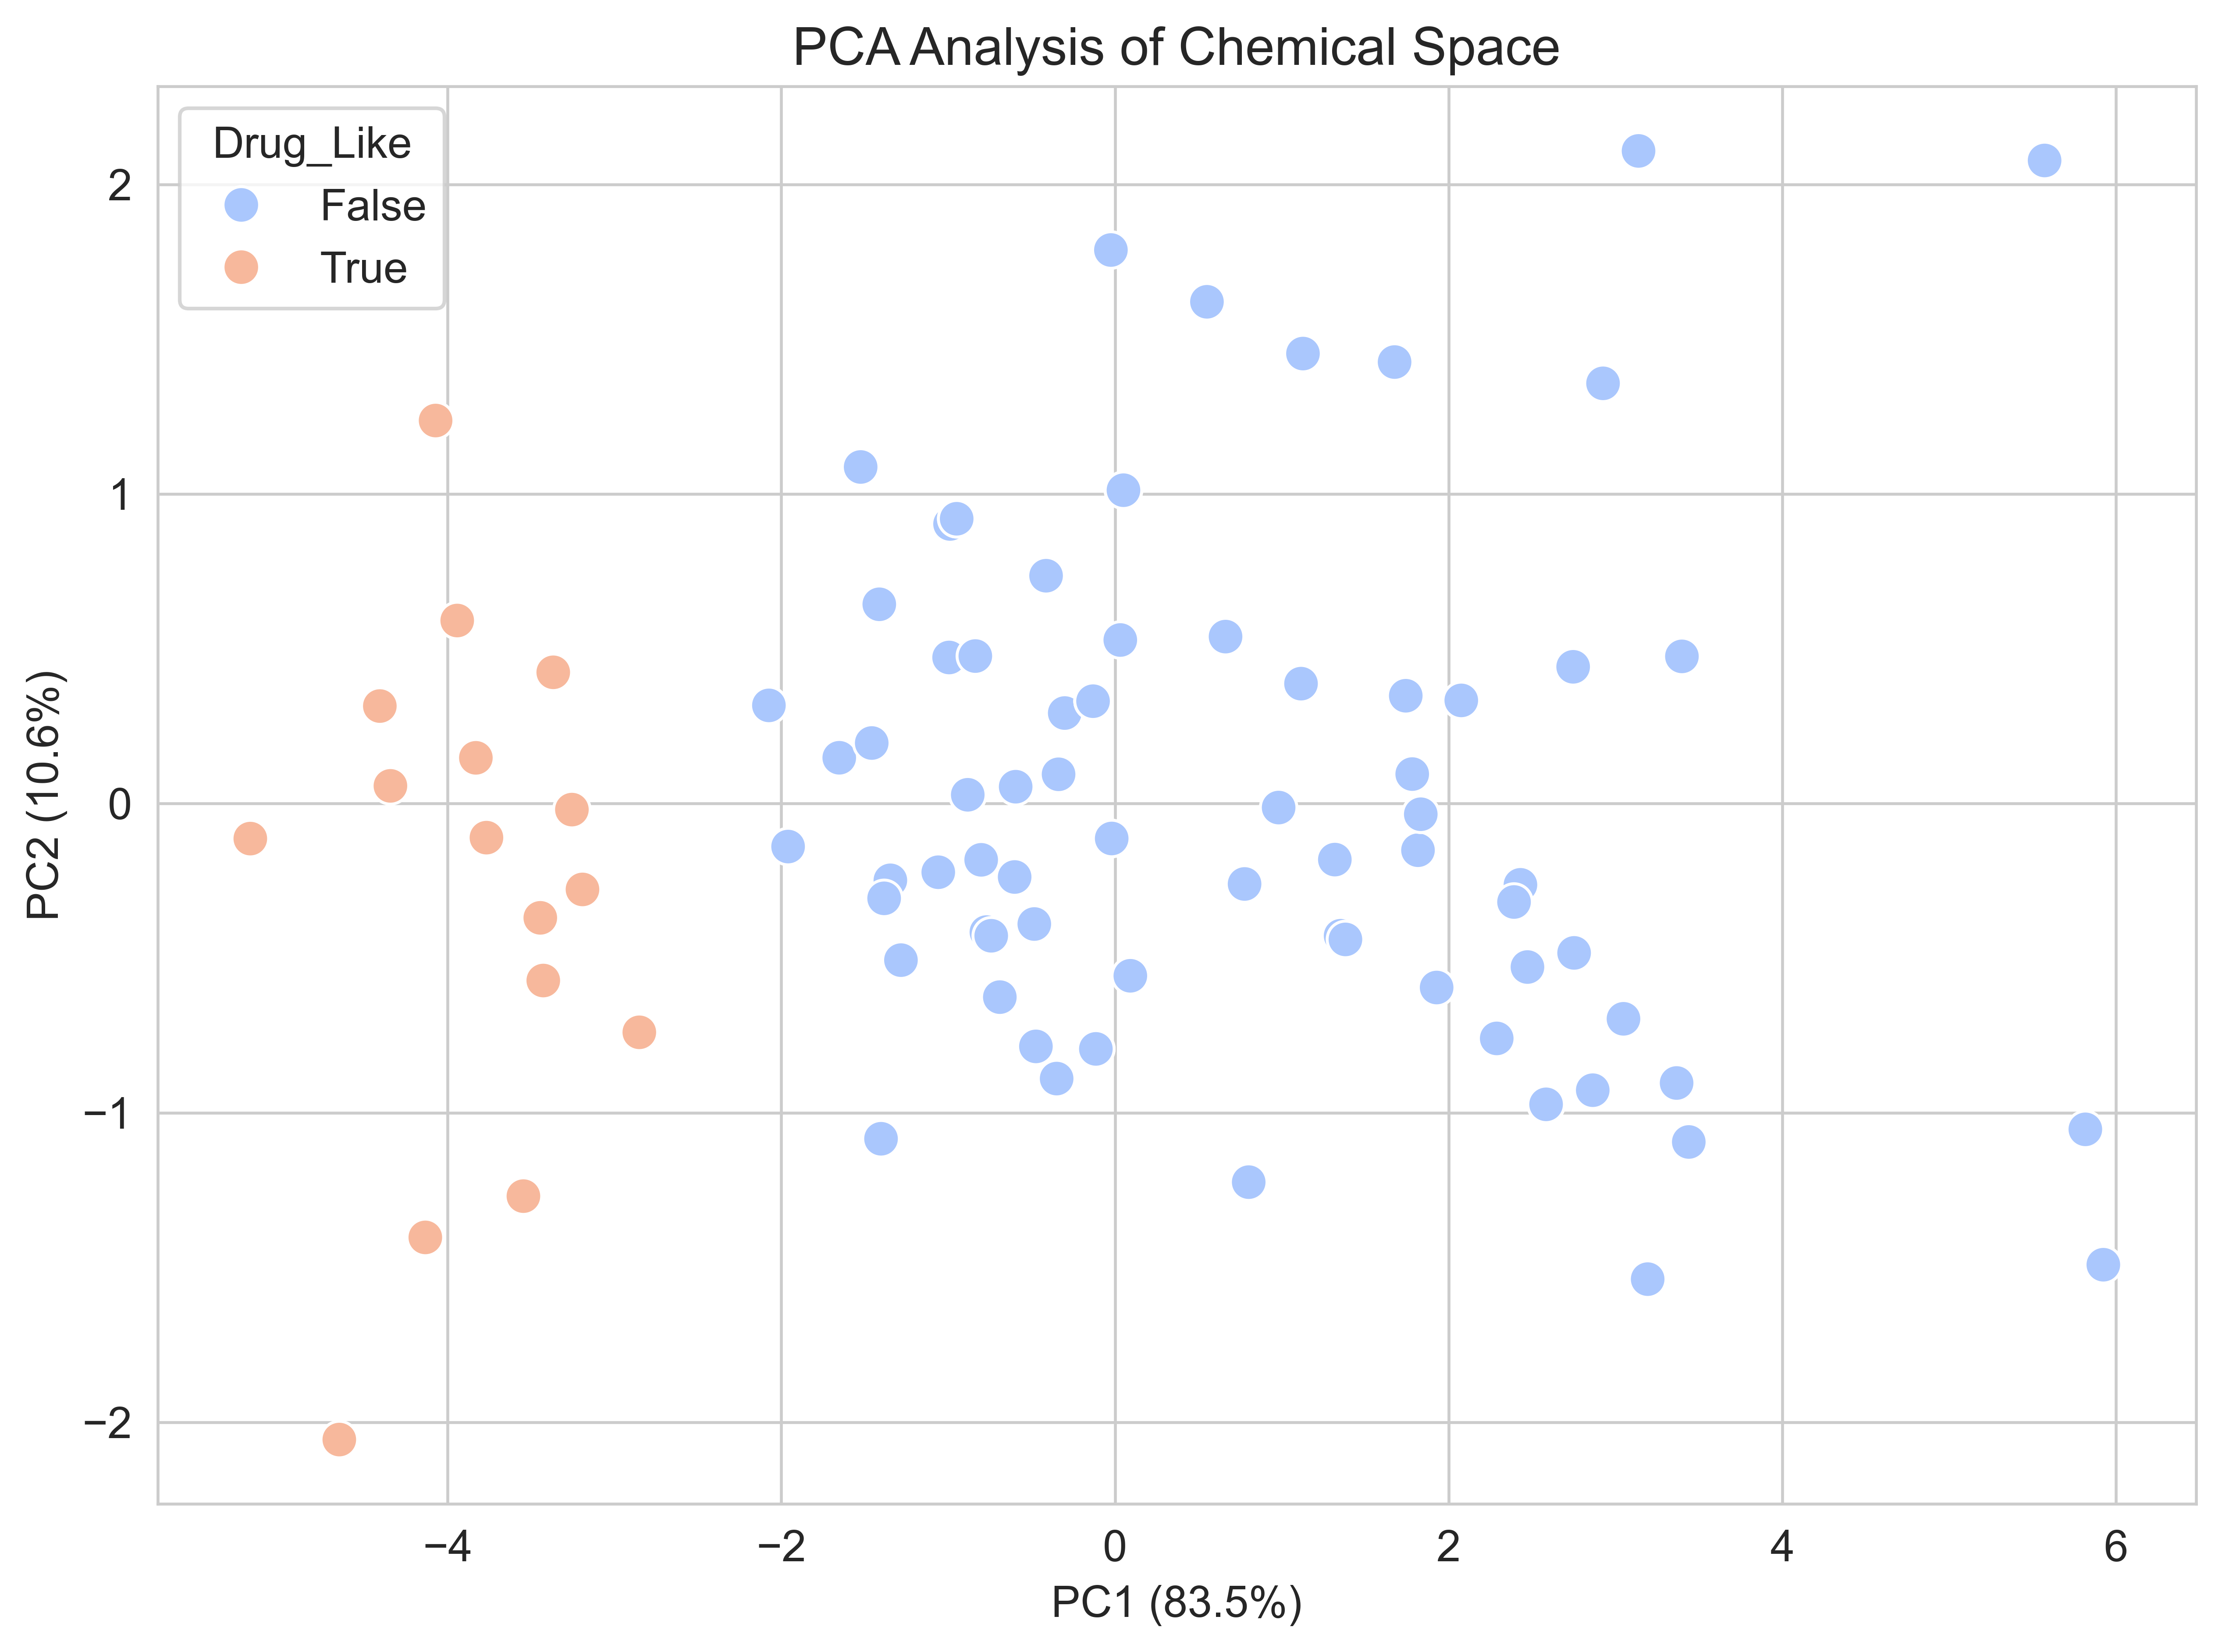

In [17]:
# ==========================================
# 5. PRINCIPAL COMPONENT ANALYSIS (PCA)
# ==========================================
# PCA reduces the dimensionality of descriptors to visualize structural diversity.
features = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotB']
x = processed_df[features].values
x_scaled = StandardScaler().fit_transform(x)

pca = PCA(n_components=2)
pc = pca.fit_transform(x_scaled)
pca_df = pd.DataFrame(data=pc, columns=['PC1', 'PC2'])
pca_df['Drug_Like'] = processed_df['Drug_Like']

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Drug_Like', palette='coolwarm', s=100)
plt.title('PCA Analysis of Chemical Space')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.savefig('PCA_Analysis.png')

print("Screening and Visualization Complete. Files saved to directory.")

In [18]:
# ==========================================
# 6. EXPORTING FINAL SCREENED CANDIDATES
# ==========================================
# Filter the dataframe to keep only those that passed all screening criteria
# 'Drug_Like' is True only if Lipinski_Pass AND Veber_Pass are both True.
screened_only_df = processed_df[processed_df['Drug_Like'] == True].reset_index(drop=True)

In [20]:
# Save the final candidates to a new CSV file
output_filename = 'Final_Screened_Molecules.csv'
screened_only_df.to_csv(output_filename, index=False)
print(f"Export Complete: {len(screened_only_df)} molecules passed all filters and were saved to {output_filename}.")

Export Complete: 16 molecules passed all filters and were saved to Final_Screened_Molecules.csv.


In [21]:
# Displaying a preview of the successful candidates
print("\nTop Candidate Preview:")
print(screened_only_df[['Name', 'MW', 'LogP', 'TPSA']].head())


Top Candidate Preview:
           Name       MW     LogP    TPSA
0      Cyanidin  287.247  2.90890  112.45
1  Pelargonidin  271.248  3.20330   92.22
2    Petunidin   317.273  2.91750  121.68
3      Malvidin  329.328  3.82332   90.45
4      Peonidin  301.274  3.21190  101.45


In [22]:
#Visualize the results for the final 16 screened candidates
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [23]:
# 1. LOAD THE FINAL SCREENED DATA
df_final = pd.read_csv('Final_Screened_Molecules.csv')

In [25]:
# Configure high-impact visual settings
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10, 'figure.dpi': 600})
features = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotB']

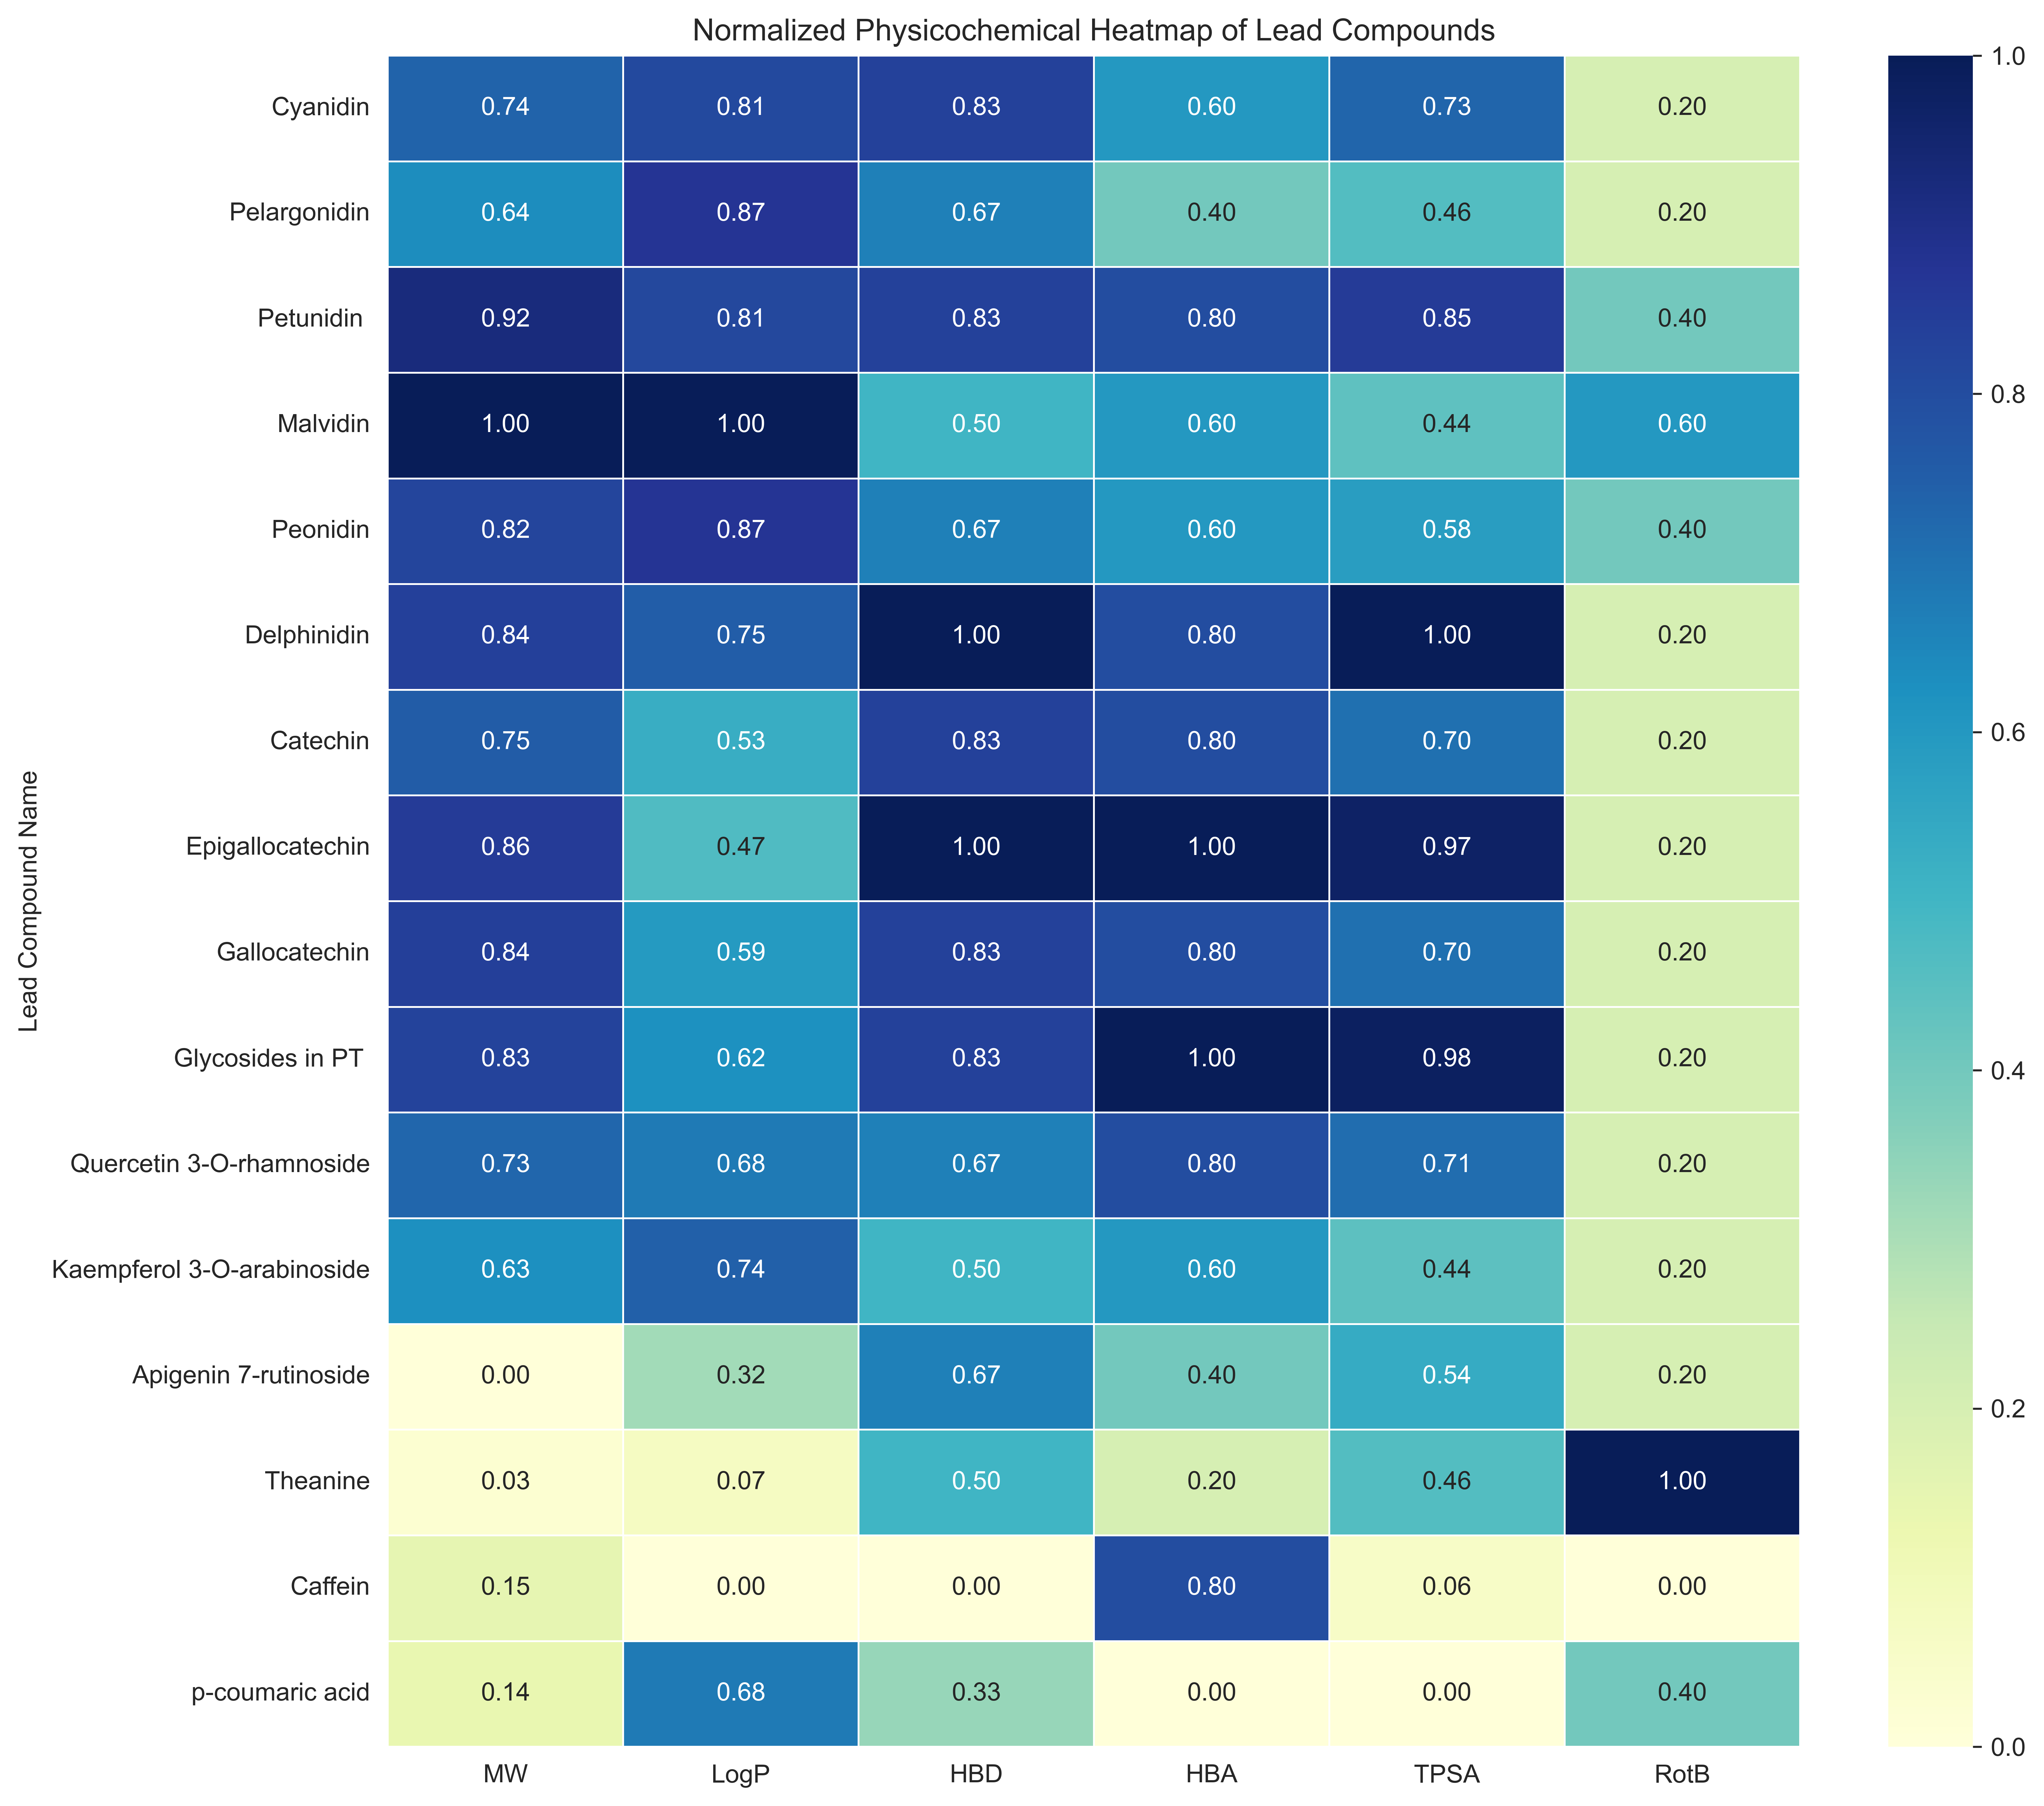

In [26]:
# 2. PROPERTY HEATMAP (NORMALIZED)
# Scaling ensures all properties (e.g., MW ~400 and LogP ~3) are visible on the same scale
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_final[features])
df_scaled = pd.DataFrame(scaled_data, columns=features, index=df_final['Name'])

plt.figure(figsize=(12, 10))
sns.heatmap(df_scaled, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5)
plt.title('Normalized Physicochemical Heatmap of Lead Compounds')
plt.ylabel('Lead Compound Name')
plt.tight_layout()
plt.savefig('Final_Screened_Heatmap.png')

In [27]:
# 3. DISTRIBUTION BOXPLOTS
# Shows the range and "tightness" of properties in the screened set
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(data=df_final, y=col, ax=axes[i], color='lightcoral', width=0.4)
    axes[i].set_title(f'Range of {col}')
plt.tight_layout()
plt.savefig('Final_Screened_Boxplots.png')

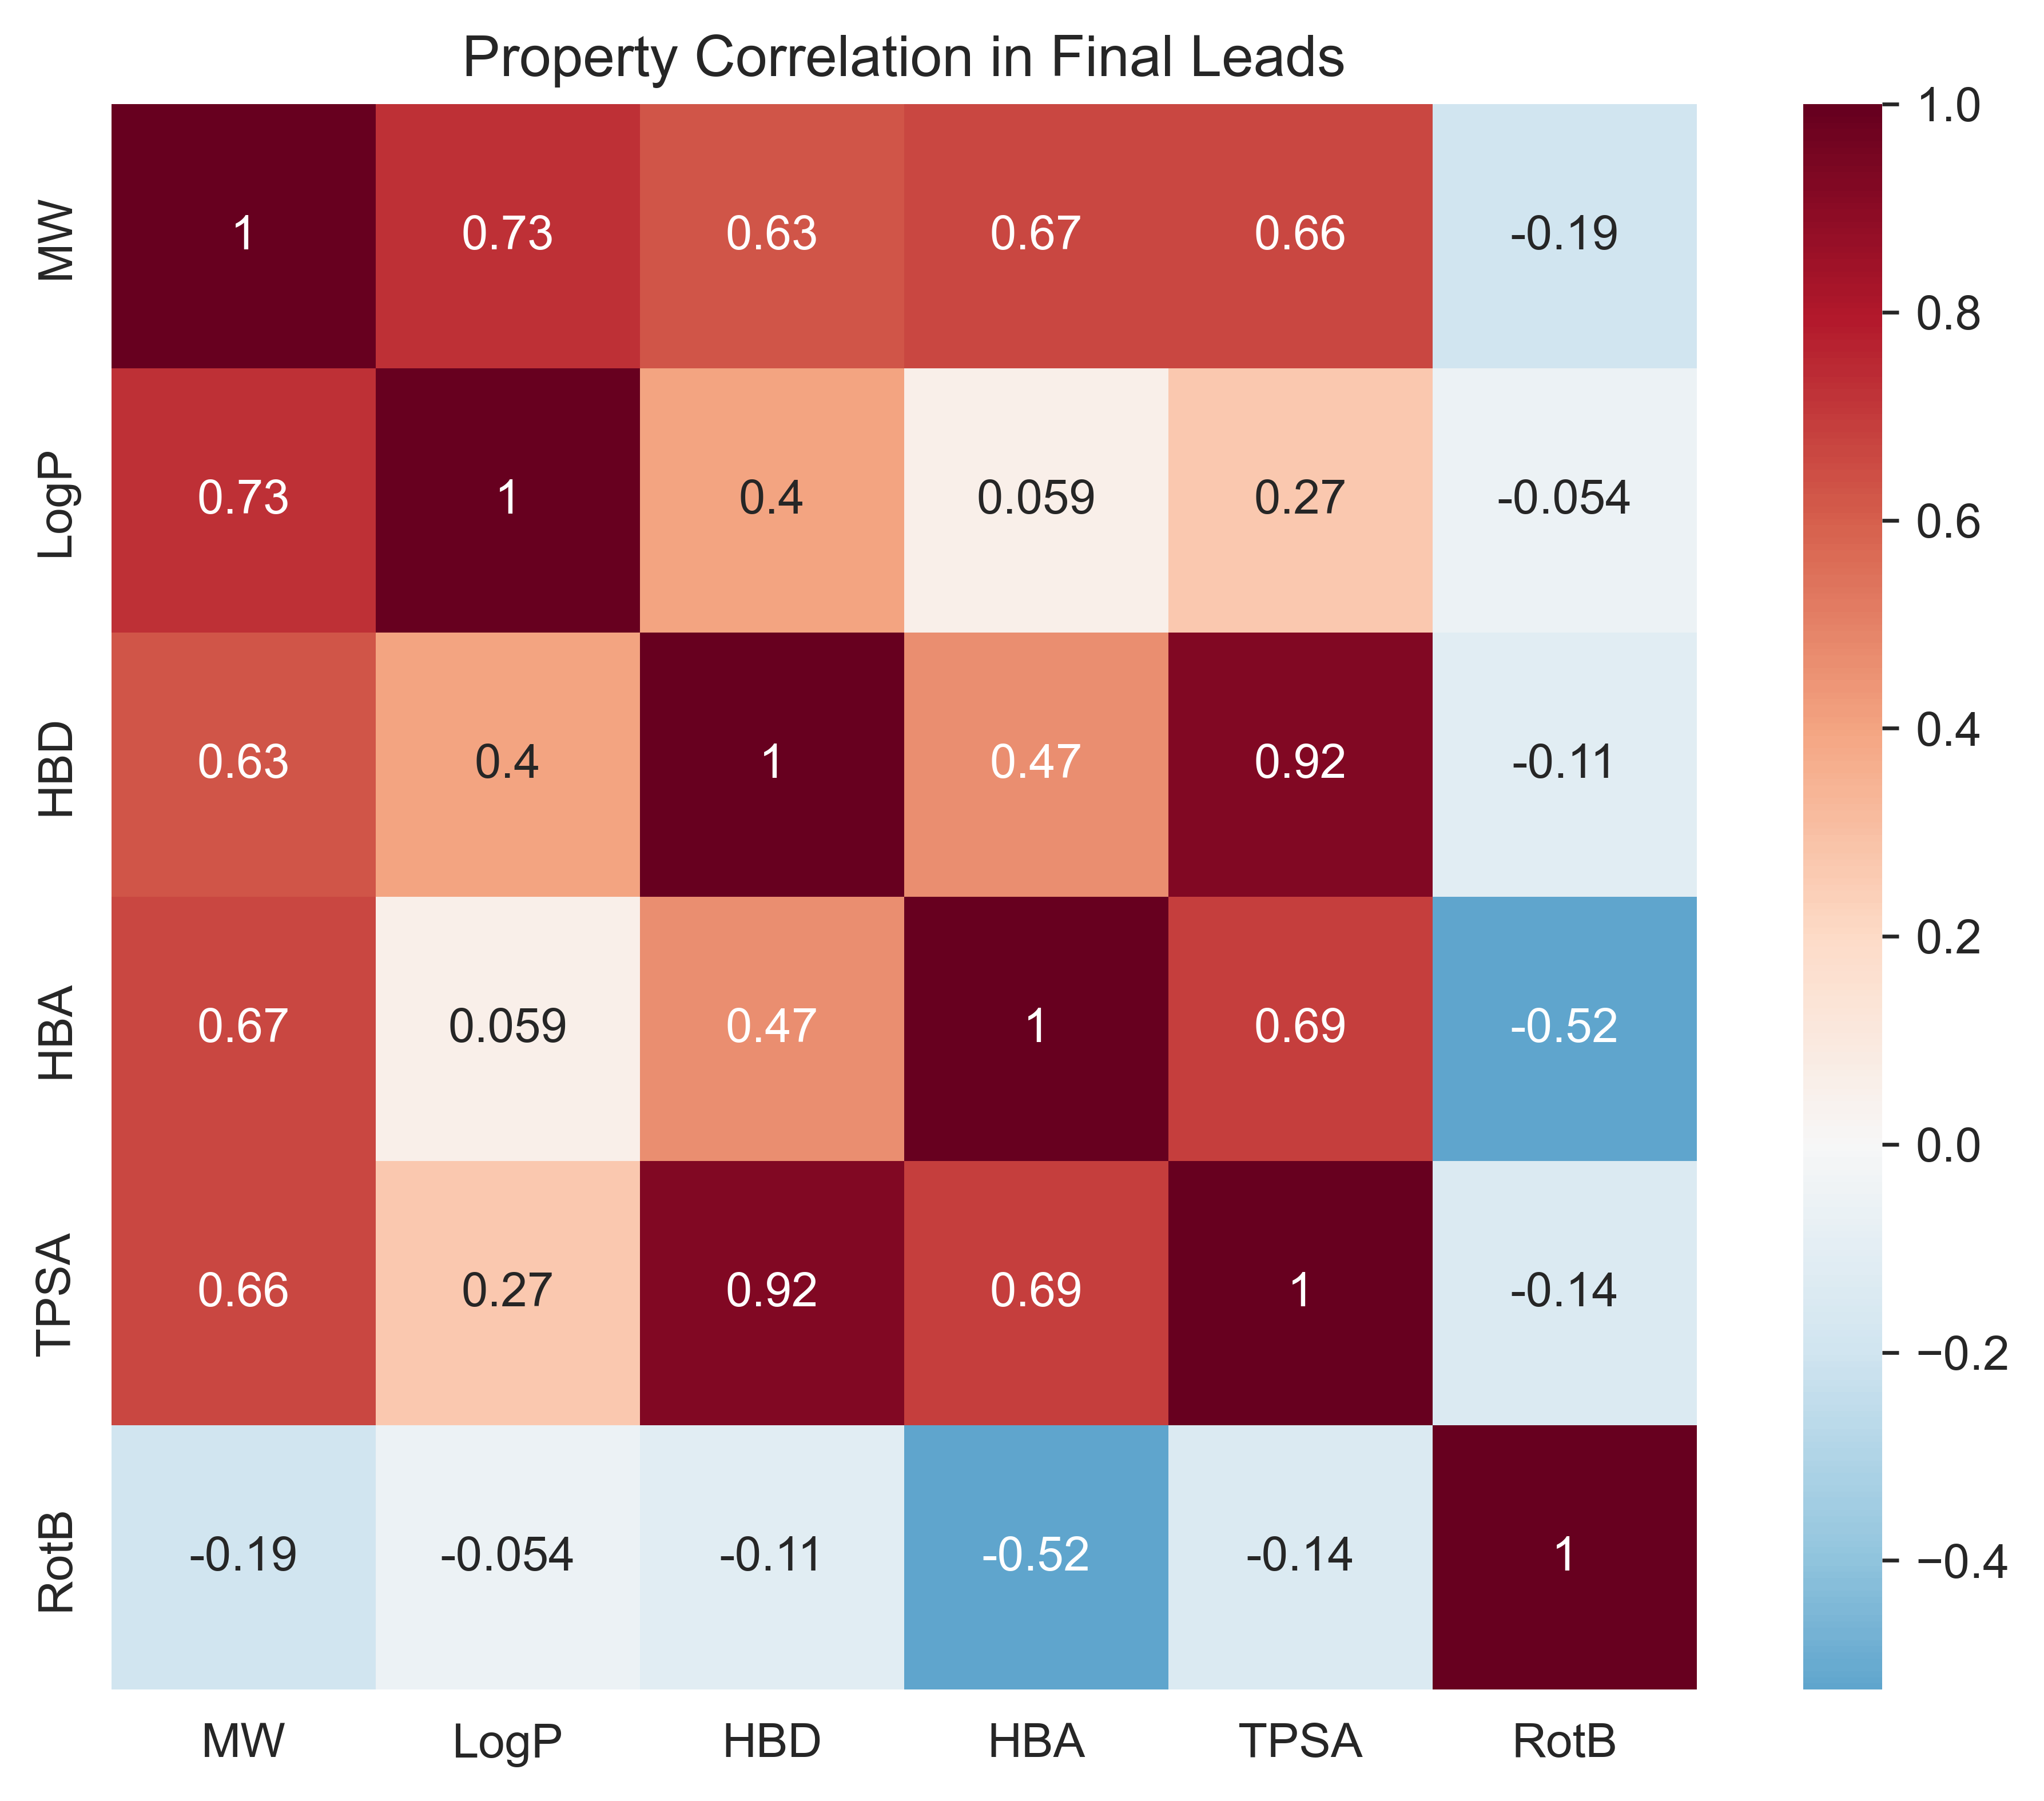

In [28]:
# 4. CORRELATION MATRIX
# To Identify if certain properties are highly linked in the lead candidates
plt.figure(figsize=(8, 6))
corr = df_final[features].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, square=True)
plt.title('Property Correlation in Final Leads')
plt.savefig('Final_Screened_Correlation.png')

In [29]:
# 5. RADAR CHART (PROPERTY PROFILING)
# This is highly effective for visual journals to show a "balanced" drug profile
def plot_radar(row_data, labels, title, filename):
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    # Close the circle
    data = np.concatenate((row_data, [row_data[0]]))
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.fill(angles, data, color='teal', alpha=0.25)
    ax.plot(angles, data, color='teal', linewidth=2)
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    plt.title(title, size=14, pad=20)
    plt.savefig(filename)

All final visualizations have been generated and saved.


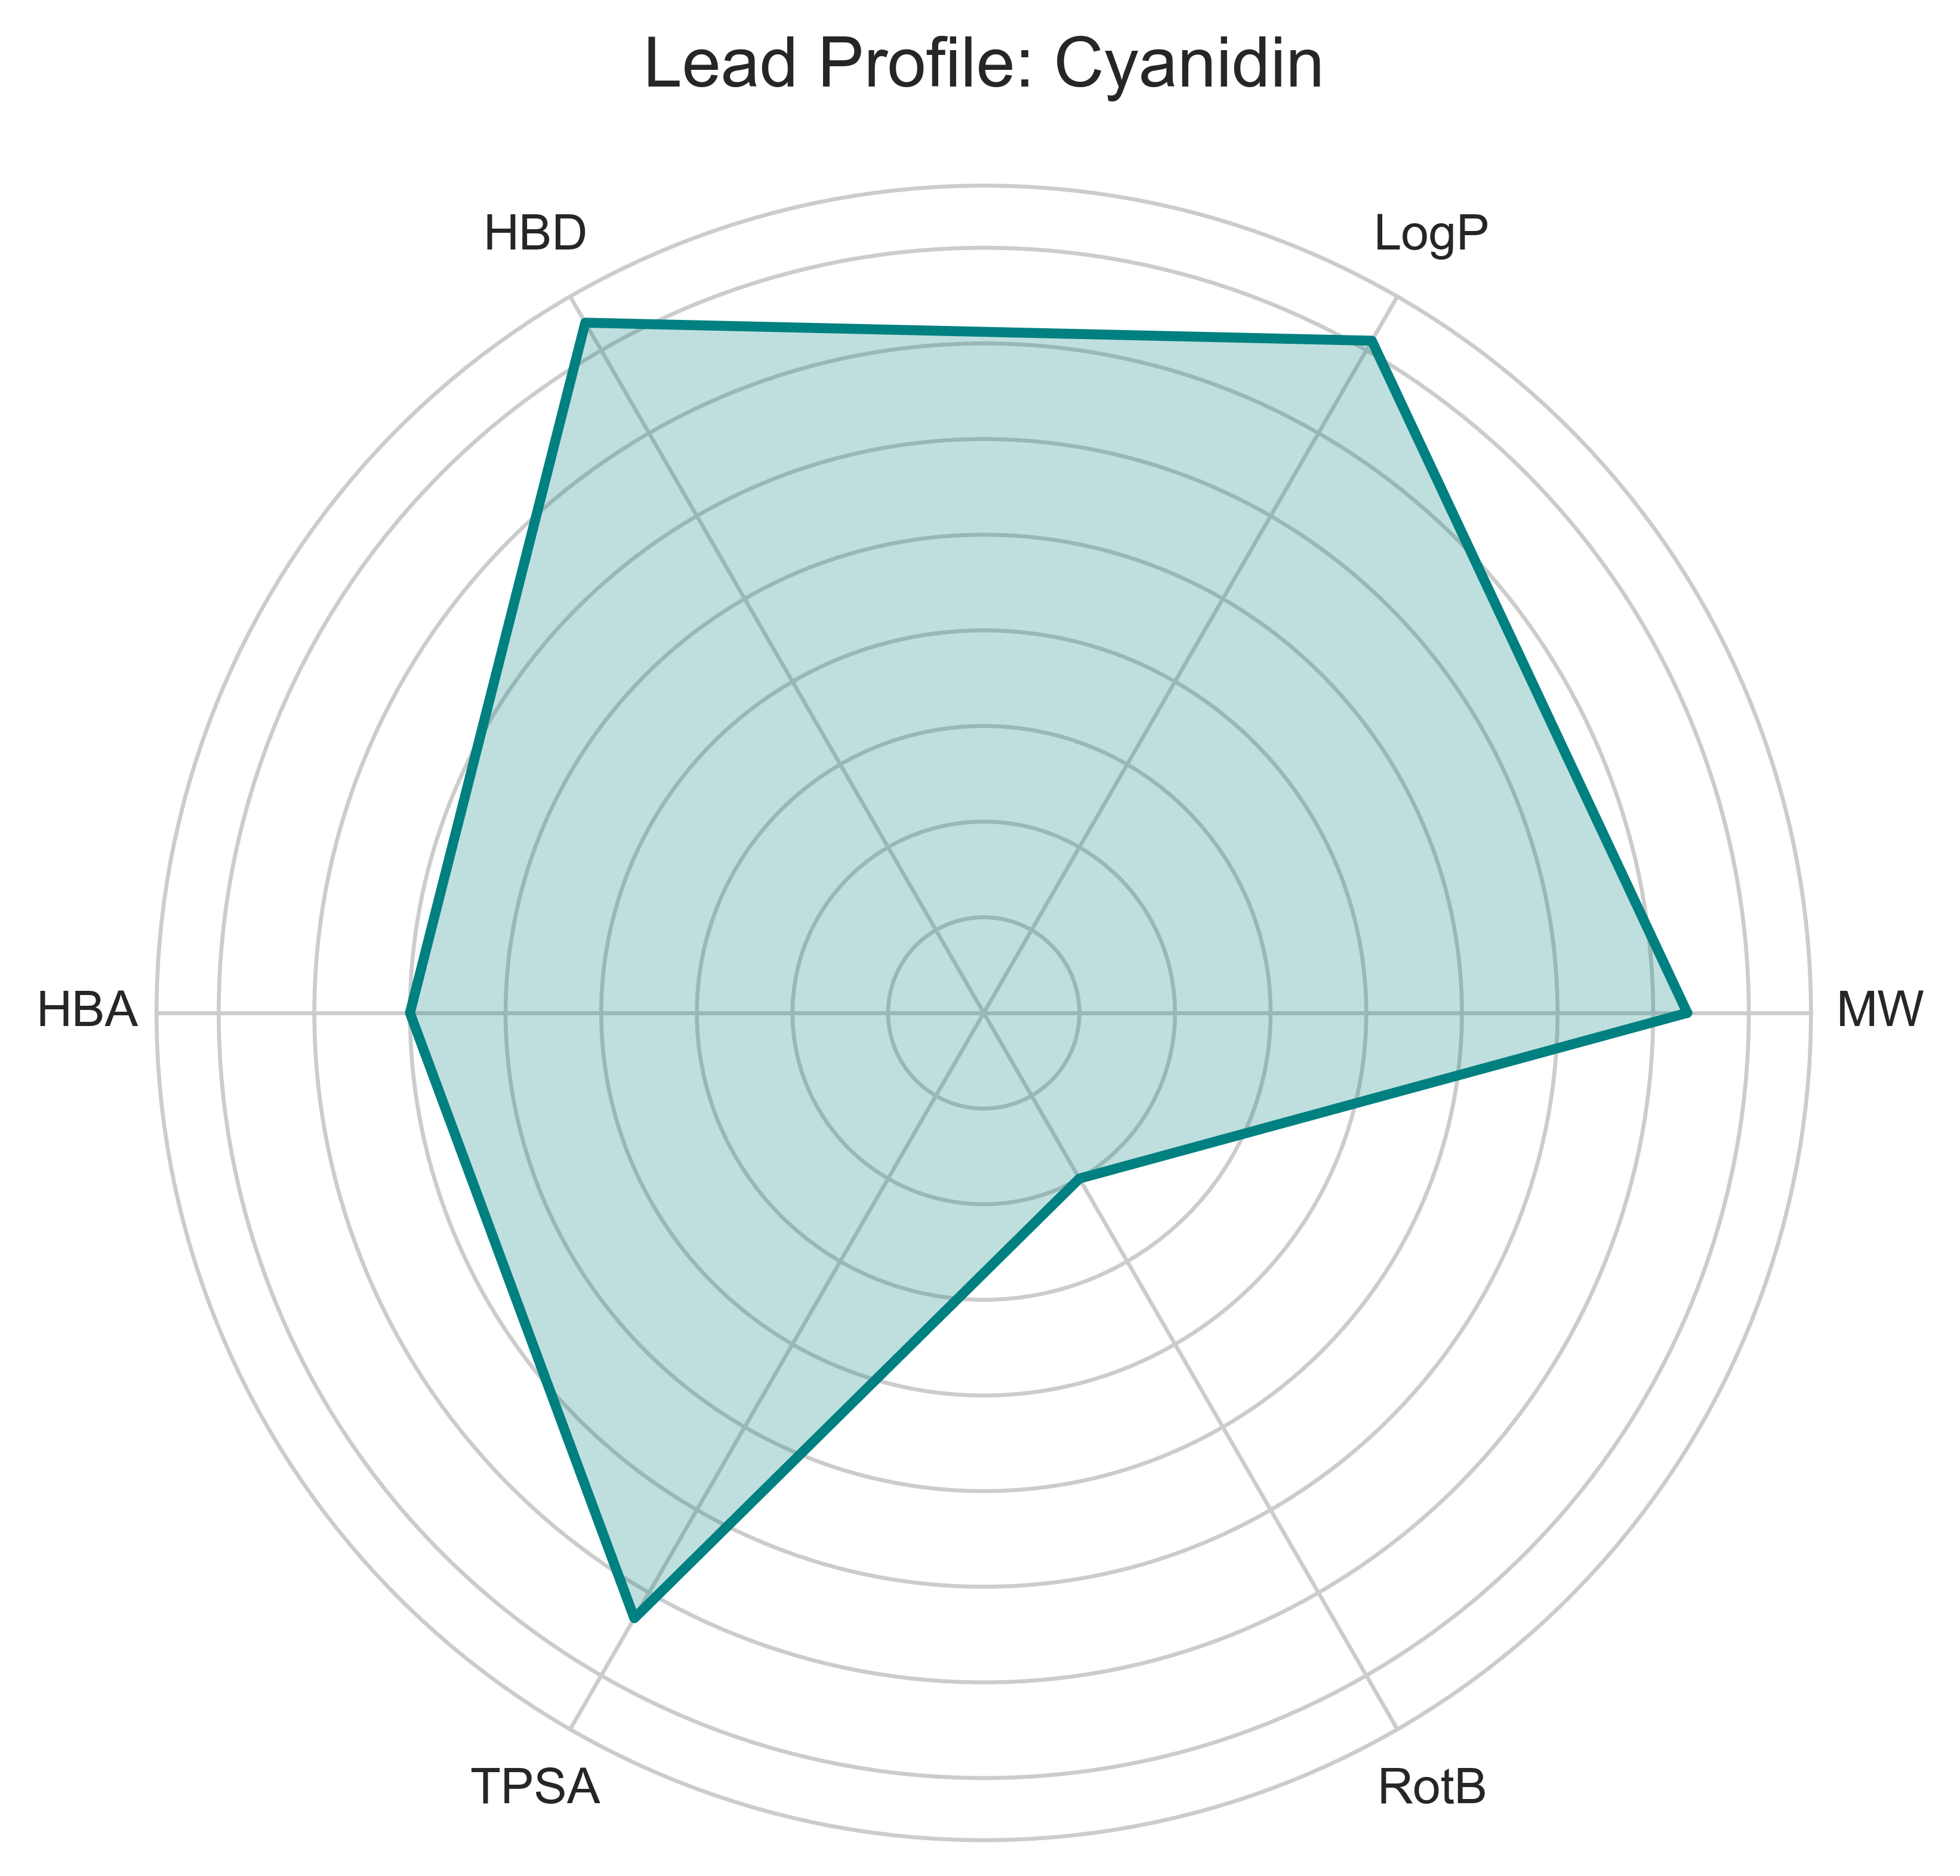

In [30]:
# Generate a radar plot for the first candidate in the list
if not df_final.empty:
    example_vals = df_scaled.iloc[0].values
    plot_radar(example_vals, features, f'Lead Profile: {df_final["Name"].iloc[0]}', 'Radar_Chart_Lead.png')

print("All final visualizations have been generated and saved.")